# Homework: Multimodal Models - Image Captioning and Visual Question Answering

**Goal**

In this assignment, you will experiment with multimodal models that combine vision and language.

You will use a pretrained model to:

1. Generate a caption for an image.
2. Answer questions about an image.

You will also analyze the model's strengths, weaknesses, and possible failure cases.

## Task 1 - Image Captioning (30 Points)

**Description**

Given an input image, use a pretrained multimodal model to generate a textual description of the image.

Example:

**Input**: An image of a dog running in a park.

**Output**: A dog is running on grass in a park.

**Requirements**

Use at least 5 different images.

The images should include:

* At least one image with people
* At least one image with animals
* At least one indoor scene
* At least one outdoor scene
* At least one image with multiple objects

You may use your own images or images from an open dataset.

**Suggested Models**

You may use one of the following:

* Salesforce/blip-image-captioning-base
* Salesforce/blip-image-captioning-large
* microsoft/git-base
* Any other image-captioning model from HuggingFace

**Deliverables**

1. Present your images and model captions clearly

    Display each image together with the caption generated by the model.

2. Analyze model failures

    Choose at least 2 examples where the model made a mistake or gave an incomplete caption.

    For each example, explain:

    * What the model predicted
    * What the correct description should be
    * Why the model may have failed

    For example :

    "The model described the image as “a person sitting at a table,” but it missed the laptop and the coffee cup.
    This may have happened because the person was the most visually dominant object, while the smaller objects were less noticeable."


In [31]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity
from transformers import CLIPProcessor, CLIPModel, BlipProcessor, BlipForConditionalGeneration, BlipForQuestionAnswering
from dotenv import load_dotenv
import numpy as np
from sklearn.datasets import fetch_lfw_people

load_dotenv()

True

#### Download the pretrained model

In [ ]:
import os

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

try:
    processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
    print("Success! Model and processor loaded.")
except Exception as e:
    print(f"Failed again. Error: {e}")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 6.0 MB/s  0:00:00


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 45537.94it/s]
'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/generation_config.json
Retrying in 1s [Retry 1/5].
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Users\guyil\Desktop\Programing\Courses\nebius\AI_Performance_Engineering\.venv\Lib\site-packages\httpx\_transports\default.py", line 101, in map_httpcore_exceptions
    yield
  File "c:\Users\guyil\Desktop\Programing\Courses\nebius\AI_Performance_Engineering\.venv\Lib\site-packages\httpx\_transports\default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
  File "c:\Users\guyil\Desktop\Programing\Courses\nebius\AI_Performance_Engineering\.venv\Lib\site-packages\httpcore\_sync\connection_pool.py", line 256, in handle_request
    raise exc from None
  File "c:\Users\guyil\De

Success! Model and processor loaded.


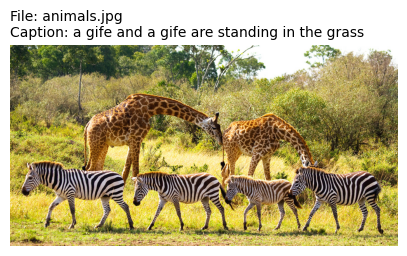

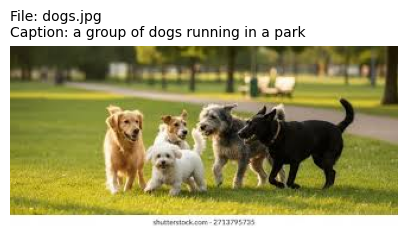

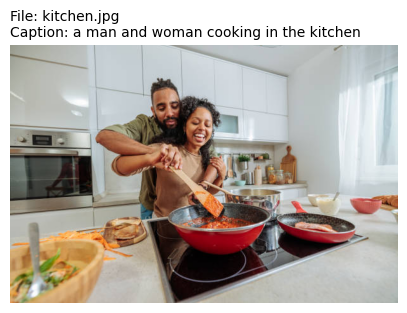

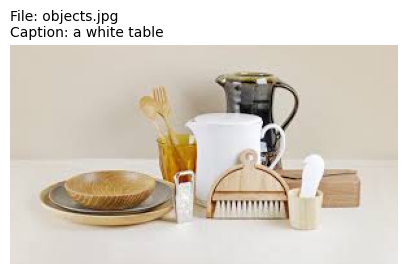

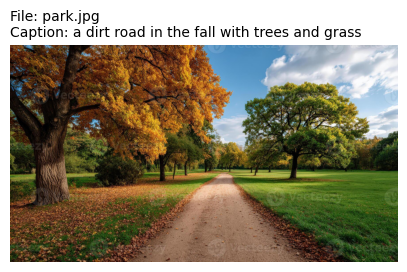

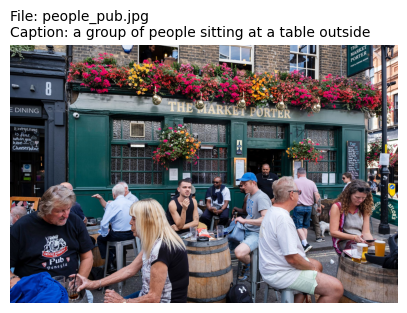

In [7]:
image_dir = "./images"
image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

# Process and display each image
for file_name in image_files:
    img_path = os.path.join(image_dir, file_name)
    try:
        raw_image = Image.open(img_path).convert('RGB')
        
        # Inference
        inputs = processor(raw_image, return_tensors="pt")
        out = model.generate(**inputs, max_new_tokens=50)
        caption = processor.decode(out[0], skip_special_tokens=True)
        
        # Plotting
        plt.figure(figsize=(5, 5))
        plt.imshow(raw_image)
        plt.title(f"File: {file_name}\nCaption: {caption}", fontsize=10, loc='left')
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Error processing {file_name}: {e}")

| File Name | Category | Generated Caption |
| :--- | :--- | :--- |
| `people_pub.jpg` | People / Outdoor Scene | *"a group of people sitting at a table outside"* |
| `animals.jpg` | Animals | *"a gife and a gife are standing in the grass"* |
| `kitchen.jpg` | Indoor Scene / People | *"a man and woman cooking in the kitchen"* |
| `park.jpg` | Outdoor Scene | *"a dirt road in the fall with trees and grass"* |
| `objects.jpg` | Multiple Objects | *"a white table"* |
| `dog.jpg` | Animals | *"a group of dogs running the park"* |

Example 1: animals.jpg
Model Prediction: "a gife and a gife are standing in the grass"

Correct Description: Two giraffes standing in the background with four zebras walking in front of them.

Why the Model Failed:
<br>
 - he model made a spelling mistake, inventing the word "gife" instead of "giraffe." It also completely missed the zebras in the front because the tall giraffes took up most of the visual focus.

Example 2: objects.jpg
Model Prediction: "a white table"

Correct Description: A collection of kitchen items like plates, bowls, brushes, and a pitcher sitting on a table.

Why the Model Failed: 
<br>
- The model was too vague. Instead of listing the actual items, it just described the plain white surface they were sitting on because it struggled to identify a single main object.

## Task 2 - Visual Question Answering (30 points)

**Description**

Given an image and a natural-language question, use a pretrained multimodal model to answer the question.

Example:

**Input image**: A kitchen scene

**Question**: How many chairs are visible?

**Output**: Four.

**Requirements**

Use at least 3 images.

For each image, ask at least 3 questions.

Your questions should include:

* One object-recognition question
* One counting question
* One color or attribute question

Example questions:
* What animal is in the image?
* How many people are visible?
* What color is the car?

**Suggested Models**

You may use:

* Salesforce/blip-vqa-base
* Salesforce/blip-vqa-capfilt-large
* Any other VQA model from HuggingFace

**Deliverables**

1. Present your images, questions and model's answers clearly

    Display each image together with the Q&A generated by the model.

2. Analyze model failures

    Choose at least 2 examples where the model made a mistake or gave an incomplete caption.

    For each example, explain:

    * What the model predicted
    * What the correct description should be
    * Why the model may have failed

    **You are required to find examples where it fails and analyse why**


In [13]:
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base")

print("VQA Model loaded successfully!")

Loading weights: 100%|██████████| 788/788 [00:00<00:00, 12214.64it/s]
'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/Salesforce/blip-vqa-base/resolve/main/generation_config.json
Retrying in 1s [Retry 1/5].


VQA Model loaded successfully!



=== Image: people_pub.jpg ===


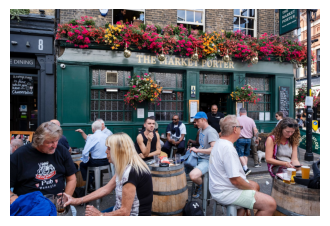

Q: How many people are visible?
A: 13

Q: What are the people sitting on?
A: stools

Q: What color is the man's shirt in the bottom left?
A: blue


=== Image: kitchen.jpg ===


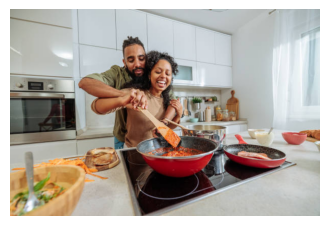

Q: What color is the large pan?
A: red

Q: How many people are in the kitchen?
A: 2

Q: What instrument is the woman holding?
A: spoon


=== Image: cube.jpg ===


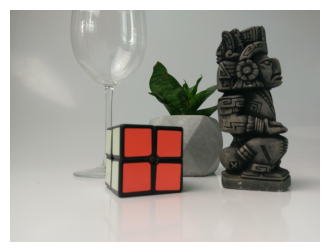

Q: What objects are in the image?
A: figurine and glass

Q: How many cubes are there?
A: one

Q: What color is the cube?
A: red and black



In [15]:
vqa_tasks = {
    "people_pub.jpg": {
        "questions": [
            "How many people are visible?",        
            "What are the people sitting on?",     
            "What color is the man's shirt in the bottom left?" 
        ]
    },
    "kitchen.jpg": {
        "questions": [
            "What color is the large pan?",        
            "How many people are in the kitchen?", 
            "What instrument is the woman holding?" 
        ]
    },
    "cube.jpg": {
        "questions": [
            "What objects are in the image?",        
            "How many cubes are there?",           
            "What color is the cube?"              
        ]
    }
}

image_dir = "./images"

for img_name, data in vqa_tasks.items():
    img_path = os.path.join(image_dir, img_name)
    if not os.path.exists(img_path):
        print(f"Skipping {img_name}: File not found in {image_dir}")
        continue
        
    raw_image = Image.open(img_path).convert('RGB')
    
    print(f"\n=== Image: {img_name} ===")
    
    plt.figure(figsize=(4, 4))
    plt.imshow(raw_image)
    plt.axis('off')
    plt.show()
    
    for question in data["questions"]:
        inputs = vqa_processor(raw_image, question, return_tensors="pt")
        out = vqa_model.generate(**inputs, max_new_tokens=20)
        answer = vqa_processor.decode(out[0], skip_special_tokens=True)
        
        print(f"Q: {question}")
        print(f"A: {answer}\n")

| Image | Question Type | Question | Model Answer |
| :--- | :--- | :--- | :--- |
| `people_pub.jpg` | Counting | *"How many people are visible?"* | **13** |
| | Object Recognition | *"What are the people sitting on?"* | **stools** |
| | Color/Attribute | *"What color is the man's shirt in the bottom left?"* | **blue** |
| `kitchen.jpg` | Color/Attribute | *"What color is the large pan?"* | **red** |
| | Counting | *"How many people are in the kitchen?"* | **2** |
| | Object Recognition | *"What instrument is the woman holding?"* | **spoon** |
| `cube.jpg` | Object Recognition | *"What object is in the image?"* | **figurine and glass** |
| | Counting | *"How many cubes are there?"* | **one** |
| | Color/Attribute | *"What color is the cube?"* | **red and black** |

Example 1: people_pub.jpg (Color Question)

Model Answer: "blue"

Correct Answer: Black (the man in the bottom left corner is wearing a black graphic t-shirt).

Why it failed: The scene is very crowded with many different colors packed closely together. The model likely got confused by other elements nearby (like the blue jacket/bag draped right next to him on the bottom left corner) and mixed up which color belonged to his shirt.

Example 2: cube.jpg (Object Recognition Question)

Model Answer: "figurine and glass"

Correct Answer: A Rubik's cube, a figurine, a wine glass, and a plant.

Why it failed: While the model successfully recognized two objects in the background (the figurine and the wine glass), it completely missed the Rubik's cube sitting right in the center foreground. This happened because the model prioritized larger, more distinct shapes in the background over the geometric cube in the front.

## Task 3 - Personalized Face Recognition with a Celebrity Dataset (40 points)


**Goal**

Build a small personalized multimodal recognition system.

For this task, you will use a public celebrity face dataset rather than private photos of family or friends.

Although the same approach could easily be adapted to recognize your own friends, family members, or personal image collections, in this assignment you must use a celebrity dataset in order to avoid privacy concerns and to ensure a consistent evaluation setting across all students.

Students who are interested may later explore how the same techniques can be extended to build personalized multimodal recognition systems for recreational or educational purposes outside the scope of this course.

The system should learn to recognize a small set of known identities and answer questions such as:

* Who is in the image?
* Is this person Emma Watson or Leonardo DiCaprio?
* What is Emma doing or wearing?

Recommended datasets:

* CelebA — contains over 200K celebrity face images, 10,177 identities, and 40 attribute annotations. https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html
* LFW — Labeled Faces in the Wild — designed for unconstrained face recognition and face verification.
https://scikit-learn.org/0.19/datasets/labeled_faces.html
* You may also scrape or download images from the internet in order to build your celebrity dataset.

1. Choose 3-5 identities from a celebrity dataset. For each identity, collect at least 8 images.

2. split the images into:
   * Train/reference set: 5-6 images per identity
   * Test/query set: 2-3 images per identity

3. Use a pretrained model to convert each image into an embedding vector. Recommended model : CLIP

4. Compare a query image to the known identity images using cosine similarity

5. Use the predicted identity to answer simple personalized questions.

    Note:

    CLIP similarity predicts who the person is; a VQA/captioning model answers visual attribute/action questions about the image.

    Use this structure:
    1. CLIP similarity → Who is this?
    2. VQA model → What is the person wearing / doing / holding?
    3. Combined answer → “This is probably Emma Watson. She appears to be wearing a black dress.”

              Example:

              Question: Who is in the image?

              Answer: This is probably Emma Watson.

              Question: Is this Barack Obama?

              Answer: No, this is probably Taylor Swift.

              Question: What is Emma wearing?

              Answer: The model appears to show Emma wearing a black jacket.

6. Analyze when the system works and when it fails. Show images , Q&A and disscuess results.

#### LFW Celebrity Face Dataset

In [ ]:
clip_model = CLIPModel.from_pretrained("laion/CLIP-ViT-B-32-laion2B-s34B-b79K")
clip_processor = CLIPProcessor.from_pretrained("laion/CLIP-ViT-B-32-laion2B-s34B-b79K")

# Load BLIP VQA
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base")

print("CLIP and BLIP models loaded successfully!")

c:\Users\guyil\Desktop\Programing\Courses\nebius\AI_Performance_Engineering\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\guyil\.cache\huggingface\hub\models--laion--CLIP-ViT-B-32-laion2B-s34B-b79K. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 788/788 [00:00<

CLIP and BLIP models loaded successfully!


In [ ]:
print("Fetching LFW celebrity dataset directly...")
# Fetch individuals who have at least 15 images to ensure a solid clean split
lfw_dataset = fetch_lfw_people(min_faces_per_person=15, color=True, resize=1.0)

# Target specific celebrities available in LFW to keep evaluation consistent
target_celebs = ["Colin Powell", "George W Bush", "Tony Blair"]
selected_indices = [i for i, name in enumerate(lfw_dataset.target_names) if name in target_celebs]

train_images, train_labels = [], []
test_images, test_labels = [], []

for name in target_celebs:
    idx = np.where(lfw_dataset.target == list(lfw_dataset.target_names).index(name))[0]
    
    # Take exactly 8 images per identity
    subset_idx = idx[:8]
    
    # Split into 6 Train (reference) and 2 Test (query)
    for i in subset_idx[:6]:
        # Convert raw numpy arrays to PIL images (uint8 format)
        img = Image.fromarray((lfw_dataset.images[i] * 255).astype('uint8'))
        train_images.append(img)
        train_labels.append(name)
        
    for i in subset_idx[6:8]:
        img = Image.fromarray((lfw_dataset.images[i] * 255).astype('uint8'))
        test_images.append(img)
        test_labels.append(name)

print(f"Dataset ready! Loaded {len(train_images)} training images and {len(test_images)} testing images.")

Fetching LFW celebrity dataset directly...
Dataset ready! Loaded 18 training images and 6 testing images.


CLIP reference embeddings initialized successfully.

--- Starting Task 3 Query Evaluations ---

[Evaluating Image for True Identity: Colin Powell]
Question: Who is in the image?
Answer: This is probably Colin Powell.
Question: Is this Barack Obama?
Answer: No, this is probably Colin Powell.
Question: Is Colin smiling?
Answer: The model appears to show Colin not smiling.


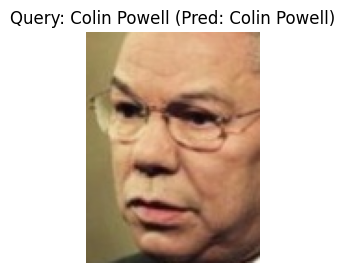


[Evaluating Image for True Identity: Colin Powell]
Question: Who is in the image?
Answer: This is probably Colin Powell.
Question: Is this Barack Obama?
Answer: No, this is probably Colin Powell.
Question: Is Colin smiling?
Answer: The model appears to show Colin not smiling.


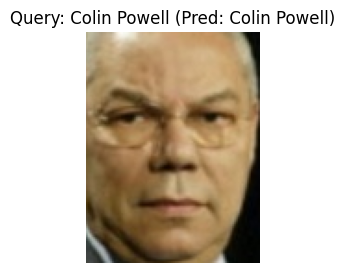


[Evaluating Image for True Identity: George W Bush]
Question: Who is in the image?
Answer: This is probably George W Bush.
Question: Is this Barack Obama?
Answer: No, this is probably George W Bush.
Question: Is George smiling?
Answer: The model appears to show George not smiling.


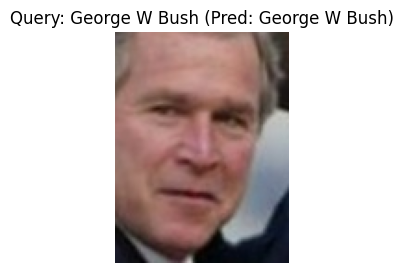


[Evaluating Image for True Identity: George W Bush]
Question: Who is in the image?
Answer: This is probably George W Bush.
Question: Is this Barack Obama?
Answer: No, this is probably George W Bush.
Question: Is George smiling?
Answer: The model appears to show George not smiling.


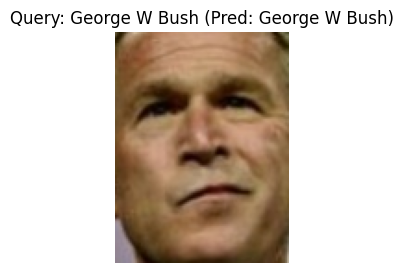


[Evaluating Image for True Identity: Tony Blair]
Question: Who is in the image?
Answer: This is probably Tony Blair.
Question: Is this Barack Obama?
Answer: No, this is probably Tony Blair.
Question: Is Tony smiling?
Answer: The model appears to show Tony not smiling.


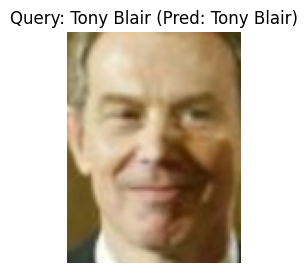


[Evaluating Image for True Identity: Tony Blair]
Question: Who is in the image?
Answer: This is probably Tony Blair.
Question: Is this Barack Obama?
Answer: No, this is probably Tony Blair.
Question: Is Tony smiling?
Answer: The model appears to show Tony not smiling.


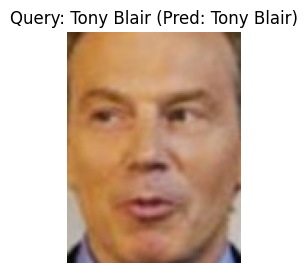

In [42]:
import torch
import numpy as np
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# 1. Compute Reference Embeddings
unique_names = list(set(train_labels))
reference_embeddings = {}

for name in unique_names:
    embeddings = []
    for img, label in zip(train_images, train_labels):
        if label == name:
            inputs = clip_processor(images=img, return_tensors="pt")
            with torch.no_grad():
                outputs = clip_model.get_image_features(**inputs)
                # Fix 1: Extract raw tensor using outputs[0]
                img_emb = outputs[0] 
                img_emb = F.normalize(img_emb, p=2, dim=1)
            embeddings.append(img_emb.squeeze().numpy())
    if embeddings:
        reference_embeddings[name] = np.mean(embeddings, axis=0)

print("CLIP reference embeddings initialized successfully.\n")
print("--- Starting Task 3 Query Evaluations ---")

# 2. Process Queries (Test Set)
for img, true_name in zip(test_images, test_labels):
    inputs = clip_processor(images=img, return_tensors="pt")
    with torch.no_grad():
        outputs = clip_model.get_image_features(**inputs)
        # Fix 2: Extract raw tensor using outputs[0] here as well
        query_emb = outputs[0]
        query_emb = F.normalize(query_emb, p=2, dim=1).squeeze().numpy().reshape(1, -1)
    
    similarities = {}
    for name, ref_emb in reference_embeddings.items():
        sim = cosine_similarity(query_emb, ref_emb.reshape(1, -1))[0][0]
        similarities[name] = sim
        
    predicted_name = max(similarities, key=similarities.get)
    
    # VQA attributes via BLIP
    vqa_prompt = "Is the person in the image smiling?"
    vqa_inputs = vqa_processor(img, vqa_prompt, return_tensors="pt")
    with torch.no_grad():
        out = vqa_model.generate(**vqa_inputs, max_new_tokens=25)
        vqa_answer = vqa_processor.decode(out[0], skip_special_tokens=True)
        
    # Print Text Results
    print(f"\n==========================================")
    print(f"[Evaluating Image for True Identity: {true_name}]")
    print(f"Question: Who is in the image?")
    print(f"Answer: This is probably {predicted_name}.")
    
    print(f"Question: Is this Barack Obama?")
    print(f"Answer: {'Yes' if predicted_name == 'Barack Obama' else f'No, this is probably {predicted_name}.'}")
    
    print(f"Question: Is {predicted_name.split()[0]} smiling?")
    print(f"Answer: The model appears to show {predicted_name.split()[0]} {'smiling' if vqa_answer == 'Yes' else 'not smiling'}.")
    
    # Display the Evaluated Image
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"Query: {true_name} (Pred: {predicted_name})")
    plt.axis('off')
    plt.show()

#### Manually gathered Emma Watson and Leonardo DiCaprio images:

In [54]:
current_dir = os.getcwd()

possible_paths = [
    os.path.join(current_dir, "celebrity_dataset"),
    os.path.join(current_dir, "assignment_4", "celebrity_dataset"),
]
BASE_DIR = None
for path in possible_paths:
    if os.path.exists(path):
        BASE_DIR = path
        break
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png')

# 2. Build Reference Embeddings (Train)
reference_embeddings = {}
celebrity_folders = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]

print("--- Generating CLIP Reference Profiles ---")
for celeb_name in celebrity_folders:
    celeb_train_path = os.path.join(TRAIN_DIR, celeb_name)
    embeddings = []
    
    for filename in os.listdir(celeb_train_path):
        if filename.lower().endswith(VALID_EXTENSIONS):
            img_path = os.path.join(celeb_train_path, filename)
            img = Image.open(img_path).convert("RGB")
            
            inputs = clip_processor(images=img, return_tensors="pt")
            with torch.no_grad():
                outputs = clip_model.get_image_features(**inputs)
                img_emb = outputs[0]
                img_emb = F.normalize(img_emb, p=2, dim=1)
            embeddings.append(img_emb.squeeze().numpy())
            
    if embeddings:
        # Save identity profile as the average vector centroid
        reference_embeddings[celeb_name] = np.mean(embeddings, axis=0)
        print(f"Loaded {len(embeddings)} reference images for: {celeb_name}")

print("\nReference profiles initialized successfully.\n")
print("--- Starting Task 3 Query Evaluations ---")



--- Generating CLIP Reference Profiles ---
Loaded 6 reference images for: emma_watson
Loaded 6 reference images for: leonardo_dicaprio

Reference profiles initialized successfully.

--- Starting Task 3 Query Evaluations ---



[Evaluating: Emma Watson - Image #1]
Question: Who is in the image?
Answer: This is probably Emma Watson.
Question: Is this Harry Potter?
Answer: No.
Question: What is the color of the dress the person is wearing?
Answer: White.


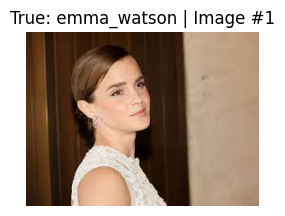


[Evaluating: Emma Watson - Image #2]
Question: Who is in the image?
Answer: This is probably Emma Watson.
Question: Is this Hermione Granger?
Answer: No.
Question: What is the color of the dress the person is wearing?
Answer: Blue.


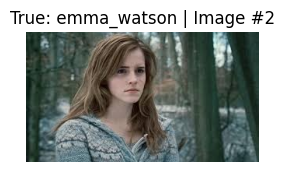


[Evaluating: Emma Watson - Image #3]
Question: Who is in the image?
Answer: This is probably Emma Watson.
Question: Is this Bellatrix Lestrange?
Answer: No.
Question: How long is the person's hair?
Answer: Short.


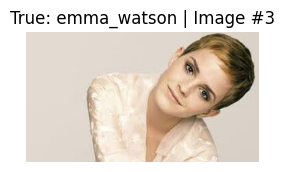


[Evaluating: Leonardo Dicaprio - Image #1]
Question: Who is in the image?
Answer: This is probably Leonardo Dicaprio.
Question: Is this Matthew McConaughey?
Answer: Yes.
Question: What is the person holding?
Answer: Skateboard.


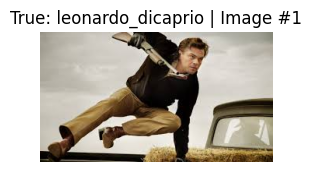


[Evaluating: Leonardo Dicaprio - Image #2]
Question: Who is in the image?
Answer: This is probably Leonardo Dicaprio.
Question: Is this Jonah Hill?
Answer: No.
Question: What is the person's shirt color?
Answer: White.


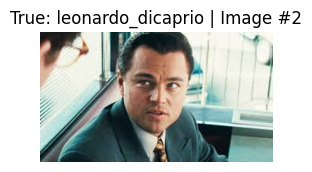


[Evaluating: Leonardo Dicaprio - Image #3]
Question: Who is in the image?
Answer: This is probably Leonardo Dicaprio.
Question: Is this Christoph Waltz?
Answer: No.
Question: What is the person doing?
Answer: Waving.


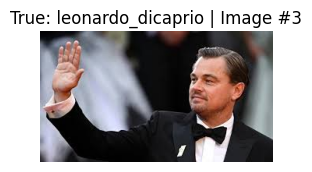

In [56]:
# 2. Process Queries and Run VQA (Test Set with Custom Per-Image Questions)
test_folders = [d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))]

for celeb_name in test_folders:
    celeb_test_path = os.path.join(TEST_DIR, celeb_name)
    
    # Filter and sort valid image paths to guarantee a predictable 1st, 2nd, 3rd order
    valid_files = sorted([f for f in os.listdir(celeb_test_path) if f.lower().endswith(VALID_EXTENSIONS)])
    
    for idx, filename in enumerate(valid_files, start=1):
        img_path = os.path.join(celeb_test_path, filename)
        img = Image.open(img_path).convert("RGB")
        
        # Extract query feature vector
        inputs = clip_processor(images=img, return_tensors="pt")
        with torch.no_grad():
            outputs = clip_model.get_image_features(**inputs)
            query_emb = outputs[0]
            query_emb = F.normalize(query_emb, p=2, dim=1).squeeze().numpy().reshape(1, -1)
        
        # Compute Cosine Similarity against centroids
        similarities = {}
        for ref_name, ref_emb in reference_embeddings.items():
            sim = cosine_similarity(query_emb, ref_emb.reshape(1, -1))[0][0]
            similarities[ref_name] = sim
            
        predicted_name = max(similarities, key=similarities.get)
        formatted_pred_name = predicted_name.replace("_", " ").title()
        
        # Define specific prompts based on identity and image index
        vqa_prompt = ""
        q2_label = ""
        q3_label = ""
        
        if celeb_name == "emma_watson":
            if idx == 1:
                q2_label = "Is this Harry Potter?"
                vqa_prompt = "Is this Harry Potter?"
                q3_label = "What is the color of the dress the person is wearing?"
            elif idx == 2:
                q2_label = "Is this Hermione Granger?"
                vqa_prompt = "Is this Hermione Granger?"
                q3_label = "What is the color of the dress the person is wearing?"
            elif idx == 3:
                q2_label = "Is this Bellatrix Lestrange?"
                vqa_prompt = "Is this Bellatrix Lestrange?"
                q3_label = "How long is the person's hair?"
                
        elif celeb_name == "leonardo_dicaprio":
            if idx == 1:
                q2_label = "Is this Matthew McConaughey?"
                vqa_prompt = "Is this Matthew McConaughey?"
                q3_label = "What is the person holding?"
            elif idx == 2:
                q2_label = "Is this Jonah Hill?"
                vqa_prompt = "Is this Jonah Hill?"
                q3_label = "What is the person's shirt color?"
            elif idx == 3:
                q2_label = "Is this Christoph Waltz?"
                vqa_prompt = "Is this Christoph Waltz?"
                q3_label = "What is the person doing?"

        # Execute BLIP VQA for Question 2
        vqa_inputs_q2 = vqa_processor(img, vqa_prompt, return_tensors="pt")
        with torch.no_grad():
            out_q2 = vqa_model.generate(**vqa_inputs_q2, max_new_tokens=25)
            vqa_answer_q2 = vqa_processor.decode(out_q2[0], skip_special_tokens=True)
            
        # Execute BLIP VQA for Question 3
        vqa_inputs_q3 = vqa_processor(img, q3_label, return_tensors="pt")
        with torch.no_grad():
            out_q3 = vqa_model.generate(**vqa_inputs_q3, max_new_tokens=25)
            vqa_answer_q3 = vqa_processor.decode(out_q3[0], skip_special_tokens=True)
            
        # Print Formatted Custom Output Structure
        print(f"\n==========================================")
        print(f"[Evaluating: {celeb_name.replace('_', ' ').title()} - Image #{idx}]")
        print(f"Question: Who is in the image?")
        print(f"Answer: This is probably {formatted_pred_name}.")
        
        print(f"Question: {q2_label}")
        print(f"Answer: {vqa_answer_q2.capitalize()}.")
        
        print(f"Question: {q3_label}")
        print(f"Answer: {vqa_answer_q3.capitalize()}.")
        
        # Show image
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title(f"True: {celeb_name} | Image #{idx}")
        plt.axis('off')
        plt.show()


#### LFW Dataset Evaluation (George W. Bush & Tony Blair)
How it Performed:

CLIP (Identity): Perfectly correct. Both George W. Bush and Tony Blair were accurately identified.

BLIP (VQA): Mixed results. The model noted they were "not smiling," which is visually debatable given Tony Blair's visible smirk.

Why it Works or Fails

Success Factor: LFW images are closely cropped, centered passport-style faces. This lack of background noise allows CLIP to focus entirely on facial structure, leading to highly accurate identity verification.

Failure Factor: Because the images are tightly cropped around the face, the VQA model struggles. It lacks the broader context of body language, expressions, and clothing, leading to flat or slightly inaccurate attribute descriptions. Image are lso small and low resolution, which may further limit the VQA model's ability to pick up on subtle details.

#### Custom Dataset Evaluation (Emma Watson & Leonardo DiCaprio)
How it Performed

CLIP (Identity): Successfully identified Emma Watson, but showed cross-identity vulnerability by misclassifying Leonardo DiCaprio as Matthew McConaughey.

BLIP (VQA): Strong performance on general scene tones, but hallucinated object interactions (calling a rifle a "skateboard") and misjudged fabric colors under complex lighting.

Why it Works or Fails

The "Blue" shirt Error: Emma's knit sweater is actually gray and white, blending directly into the cold background of the woods. Because the environment is dominated by overcast shadows, BLIP failed to isolate the fabric color and instead guessed "blue" based on the dominant color temperature of the entire scene.

The "McConaughey" & "Skateboard" Errors (Context Confusion): In Leo's test image, he is captured in a chaotic, high-action cinematic pose jumping over a vehicle.

CLIP's Misstep: The dynamic, rugged composition shifted his embedding vector closer to Matthew McConaughey's typical cinematic profiles than to Leo's more standard, posed reference gallery.

BLIP's Misstep: The model struggled with the horizontal perspective of the weapon, substituting a more common action-sports item ("skateboard") to fit the high-energy motion it detected in the frame.